# Convolutional Neural Network (CNN) for CIFAR-10 Image Classification

In [2]:
"""
Convolutional Neural Network (CNN) for CIFAR-10 Image Classification

This notebook demonstrates a full pipeline for training a deep CNN on the CIFAR-10 dataset using TensorFlow/Keras.
It includes data augmentation, GPU and thread configuration, early stopping, and training visualization via TensorBoard.
Performance is evaluated using validation accuracy and classification metrics.

Key Features:
- Dataset: CIFAR-10 (10 image classes, 32x32 RGB)
- Model: Multi-layer CNN with dropout
- Augmentation: Real-time with Keras ImageDataGenerator
- Logging: TensorBoard + Pandas tracking
- Evaluation: Accuracy, loss, and sklearn classification report
"""


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets import cifar10

import datetime
from sklearn.metrics import classification_report

# GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(e)

# CPU threading
tf.config.threading.set_intra_op_parallelism_threads(32)
tf.config.threading.set_inter_op_parallelism_threads(32)


2025-05-02 22:30:09.288455: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-02 22:30:09.296754: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746250209.306464  902112 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746250209.309405  902112 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746250209.317653  902112 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

GPU memory growth enabled


/tmp/ipykernel_902112/2501081099.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[index])], fontsize=10)


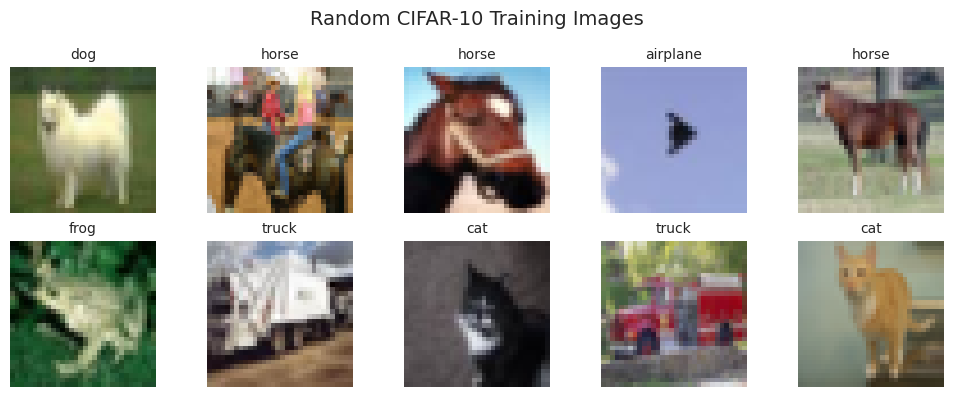

In [12]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

import random

# CIFAR-10 class labels
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Plot a 2x5 grid of random training images
plt.figure(figsize=(10, 4))
for i in range(10):
    index = random.randint(0, len(x_train) - 1)
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[index])
    plt.title(class_names[int(y_train[index])], fontsize=10)
    plt.axis('off')

plt.suptitle("Random CIFAR-10 Training Images", fontsize=14)
plt.tight_layout()
plt.show()



In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

y_cat_train = to_categorical(y_train, 10)
y_cat_test = to_categorical(y_test, 10)


In [5]:
log_dir = "/mnt/mls/logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1, write_graph=True)


In [6]:

datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2,
)
datagen.fit(x_train)


In [7]:
model = Sequential()
model.add(Input(shape=(32, 32, 3)))

model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


I0000 00:00:1746250211.799000  902112 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22362 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:01:00.0, compute capability: 8.6


In [8]:
# Helps prevent overfitting by halting early
early_stop = EarlyStopping(
    monitor='val_loss',  # Watch validation loss
    patience=10  # Wait 10 epochs before stopping
)

from tensorflow.keras.callbacks import ReduceLROnPlateau

# Helps model refine weights with smaller steps when progress slows
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # Watch validation loss
    factor=0.5,  # Cut learning rate in half
    patience=3,  # Wait 3 epochs of no improvement before reducing
    min_lr=1e-6,  # Don't let learning rate fall below this
    verbose=1  # Print updates to console
)

from tensorflow.keras.callbacks import ModelCheckpoint

# Useful if the best accuracy happens before training finishes
model_checkpoint = ModelCheckpoint(
    filepath="best_model.keras",  # Where to save the best model
    monitor="val_loss",  # Save when validation loss improves
    save_best_only=True,  # Only keep the best version
    verbose=1  # Print when a model is saved
)


In [9]:
history = model.fit(
    datagen.flow(x_train, y_cat_train, batch_size=16),
    validation_data=(x_test, y_cat_test),
    epochs=50,
    callbacks=[early_stop, tensorboard_callback, reduce_lr],
    verbose=1
)

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6882 - loss: 0.9125 - val_accuracy: 0.7198 - val_loss: 0.8301 - learning_rate: 5.0000e-04
Epoch 23/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6900 - loss: 0.9114 - val_accuracy: 0.7197 - val_loss: 0.8598 - learning_rate: 5.0000e-04
Epoch 24/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6962 - loss: 0.8950 - val_accuracy: 0.7327 - val_loss: 0.7921 - learning_rate: 5.0000e-04
Epoch 25/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6982 - loss: 0.8963 - val_accuracy: 0.7300 - val_loss: 0.8083 - learning_rate: 5.0000e-04
Epoch 26/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6988 - loss: 0.8933 - val_accuracy: 0.7351 - val_loss: 0.7699 - learning_rate: 5.0000e-04
Epoch 27/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6985 - loss: 0.8851 - val_accuracy: 0.7275 - val_loss: 0.8013 - learning_rate: 5.0000e-04
Epoch 28/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/s

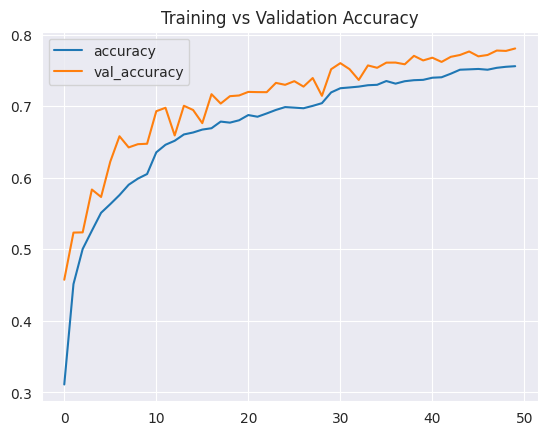

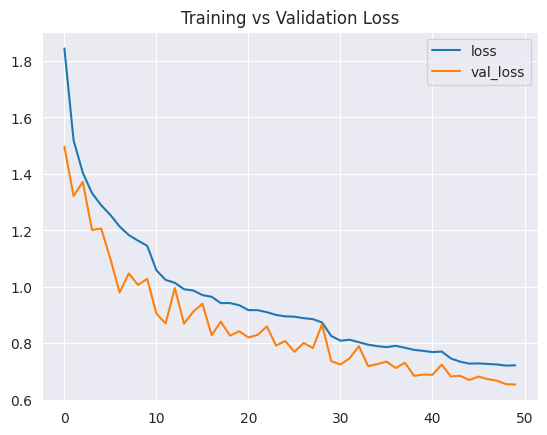

In [10]:
metrics = pd.DataFrame(history.history)

metrics[['accuracy', 'val_accuracy']].plot(title="Training vs Validation Accuracy")
plt.show()

metrics[['loss', 'val_loss']].plot(title="Training vs Validation Loss")
plt.show()


In [11]:
predictions = model.predict(x_test)
pred_labels = np.argmax(predictions, axis=1)

print(classification_report(y_test, pred_labels))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

           0       0.80      0.81      0.80      1000
           1       0.91      0.90      0.90      1000
           2       0.83      0.59      0.69      1000
           3       0.66      0.55      0.60      1000
           4       0.77      0.75      0.76      1000
           5       0.73      0.70      0.71      1000
           6       0.75      0.89      0.81      1000
           7       0.70      0.88      0.78      1000
           8       0.91      0.83      0.87      1000
           9       0.79      0.92      0.85      1000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.78     10000
weighted avg       0.78      0.78      0.78     10000

